In [1]:
from azureml.core import Workspace
ws = Workspace.from_config()
ws

Workspace.create(name='cmrmlop', subscription_id='8c1b6ca9-621a-49a3-845f-7a210ebc5ff5', resource_group='cmr')

In [2]:

# azureml-core of version 1.0.72 or higher is required
# azureml-dataprep[pandas] of version 1.1.34 or higher is required
from azureml.core import Workspace, Dataset

subscription_id = '8c1b6ca9-621a-49a3-845f-7a210ebc5ff5'
resource_group = 'cmr'
workspace_name = 'cmrmlop'

workspace = Workspace(subscription_id, resource_group, workspace_name)

dataset = Dataset.get_by_name(workspace, name='personalloan')
dataset.to_pandas_dataframe()

{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}


,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [3]:
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve
)

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [5]:
# -------------------------
# BEAUTIFYING PLOTS
# -------------------------
sns.set(style="whitegrid")

# 

In [9]:
from azureml.core import Workspace, Dataset

ws = Workspace.from_config()
dataset = Dataset.get_by_name(ws, name="personalloan")
df = dataset.to_pandas_dataframe()

df.head()

{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}


,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [10]:
print("\n--- SHAPE ---")
print(df.shape)

print("\n--- FIRST 10 ROWS ---")
print(df.head(10))

print("\n--- COLUMNS ---")
print(df.columns)

print("\n--- DATA TYPES ---")
print(df.dtypes)

print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

print("\n--- DUPLICATES REMOVED ---")
df = df.drop_duplicates()
print(df.shape)


--- SHAPE ---
(5000, 14)

--- FIRST 10 ROWS ---
   ID  Age  Experience  Income  ZIP Code  Family  CCAvg  Education  Mortgage  \
0   1   25           1      49     91107       4    1.6          1         0   
1   2   45          19      34     90089       3    1.5          1         0   
2   3   39          15      11     94720       1    1.0          1         0   
3   4   35           9     100     94112       1    2.7          2         0   
4   5   35           8      45     91330       4    1.0          2         0   
5   6   37          13      29     92121       4    0.4          2       155   
6   7   53          27      72     91711       2    1.5          2         0   
7   8   50          24      22     93943       1    0.3          3         0   
8   9   35          10      81     90089       3    0.6          2       104   
9  10   34           9     180     93023       1    8.9          3         0   

   Personal Loan  Securities Account  CD Account  Online  CreditCard  

In [11]:
# =========================
# 3. DATA CLEANING
# =========================

# Drop unnecessary columns
if 'ID' in df.columns:
    df = df.drop("ID", axis=1)

# Fix negative Experience values
df["Experience"] = df["Experience"].apply(lambda x: abs(x))


--- TARGET VALUE COUNTS ---
0    4520
1     480
Name: Personal Loan, dtype: int64


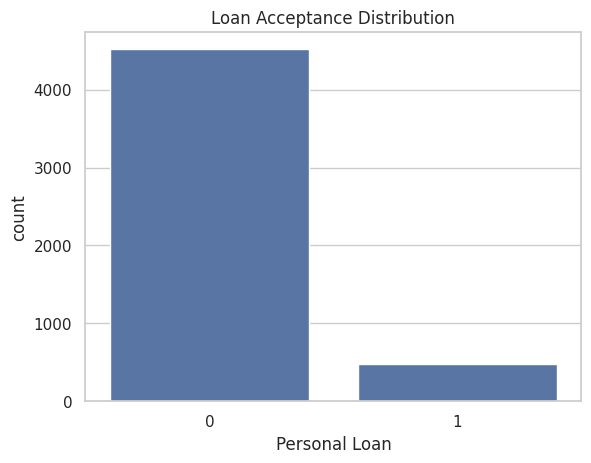

In [12]:
# 4. TARGET ANALYSIS
# =========================
print("\n--- TARGET VALUE COUNTS ---")
print(df["Personal Loan"].value_counts())

sns.countplot(data=df, x="Personal Loan")
plt.title("Loan Acceptance Distribution")
plt.show()

In [13]:
# 5. SUMMARY STATS
# =========================
print("\n--- SUMMARY STATISTICS ---")
print(df.describe())

# 


--- SUMMARY STATISTICS ---
               Age   Experience       Income      ZIP Code       Family  \
count  5000.000000  5000.000000  5000.000000   5000.000000  5000.000000   
mean     45.338400    20.134600    73.774200  93152.503000     2.396400   
std      11.463166    11.415189    46.033729   2121.852197     1.147663   
min      23.000000     0.000000     8.000000   9307.000000     1.000000   
25%      35.000000    10.000000    39.000000  91911.000000     1.000000   
50%      45.000000    20.000000    64.000000  93437.000000     2.000000   
75%      55.000000    30.000000    98.000000  94608.000000     3.000000   
max      67.000000    43.000000   224.000000  96651.000000     4.000000   

             CCAvg    Education     Mortgage  Personal Loan  \
count  5000.000000  5000.000000  5000.000000    5000.000000   
mean      1.937938     1.881000    56.498800       0.096000   
std       1.747659     0.839869   101.713802       0.294621   
min       0.000000     1.000000     0.000000

In [14]:
# 6. UNIQUE VALUES
# =========================
for col in df.columns:
    print(col, ":", df[col].nunique())

Age : 45
Experience : 44
Income : 162
ZIP Code : 467
Family : 4
CCAvg : 108
Education : 3
Mortgage : 347
Personal Loan : 2
Securities Account : 2
CD Account : 2
Online : 2
CreditCard : 2


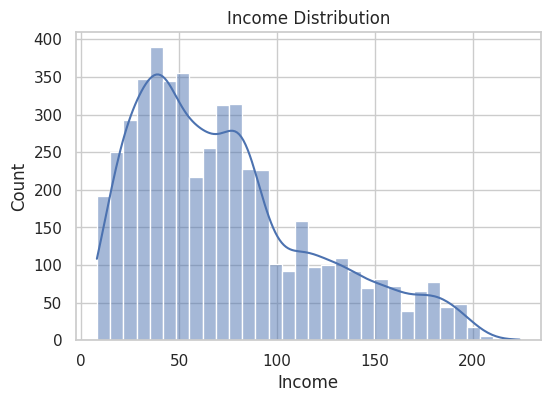

In [15]:
plt.figure(figsize=(6, 4))
sns.histplot(df["Income"], kde=True)
plt.title("Income Distribution")
plt.show()

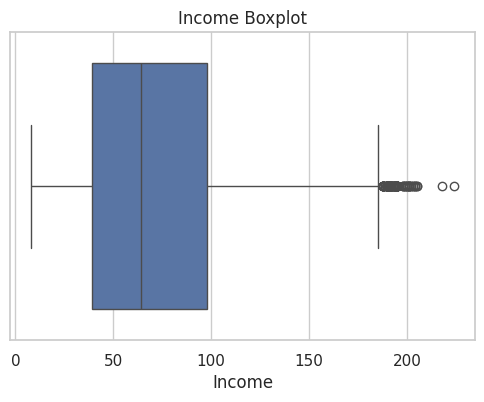

In [16]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df["Income"])
plt.title("Income Boxplot")
plt.show()

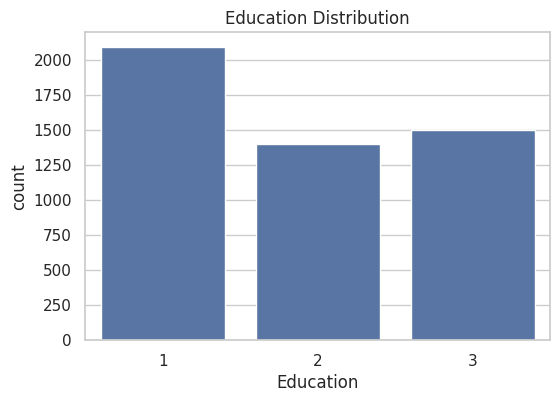

In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Education")
plt.title("Education Distribution")
plt.show()

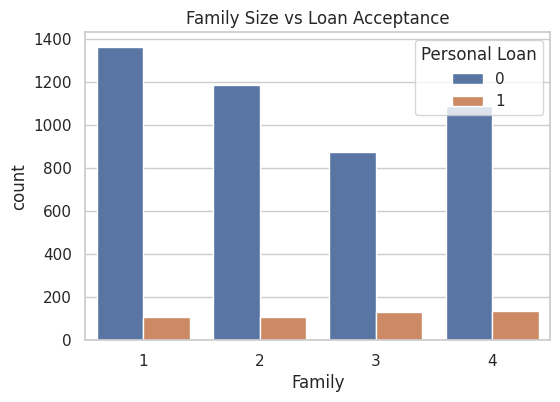

In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Family", hue="Personal Loan")
plt.title("Family Size vs Loan Acceptance")
plt.show()

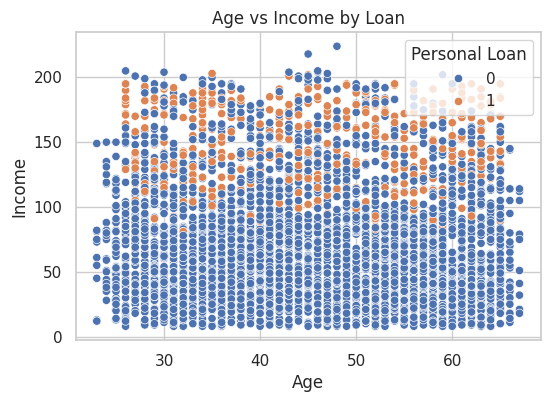

In [19]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="Age", y="Income", hue="Personal Loan")
plt.title("Age vs Income by Loan")
plt.show()

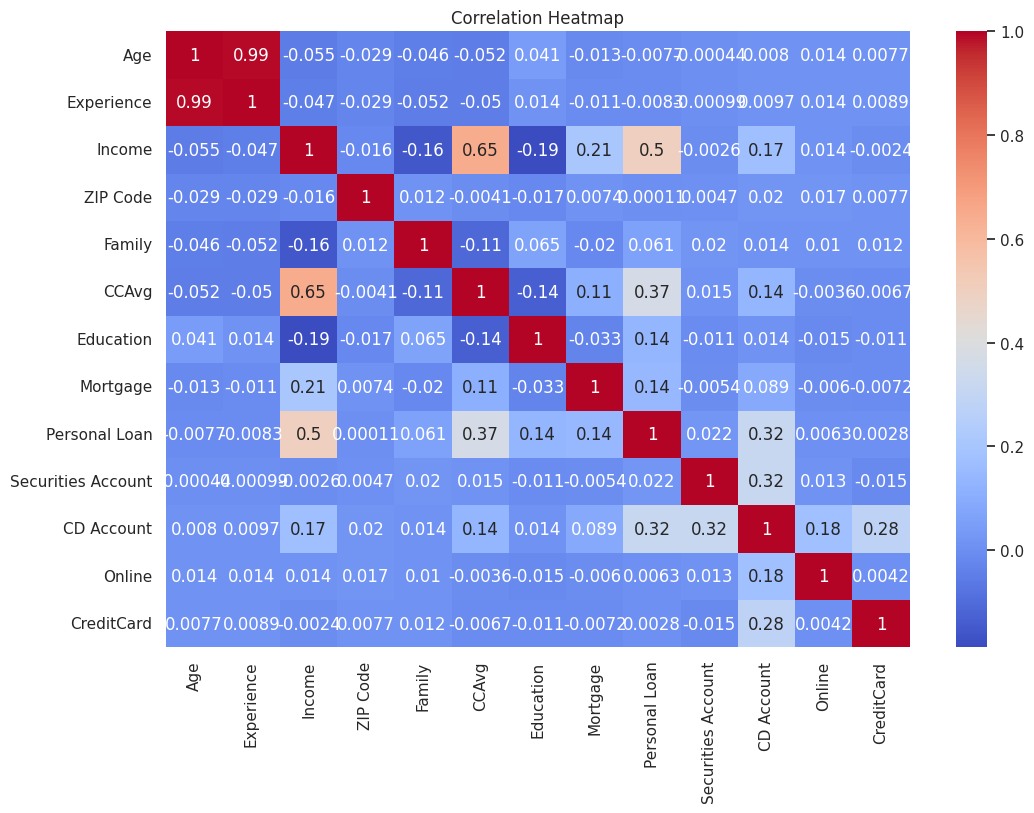

In [20]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [21]:
df["Debt_Ratio"] = (df["CCAvg"] + df["Mortgage"]) / (df["Income"] + 1)
df["Income_per_Family"] = df["Income"] / (df["Family"] + 1)
df["Experience_Ratio"] = df["Experience"] / (df["Age"] + 1)

# Age Bins
df["Age_Group"] = pd.cut(df["Age"], bins=[20, 30, 40, 50, 60, 80],
                         labels=["20-30", "30-40", "40-50", "50-60", "60+"])

# Income Bins
df["Income_Level"] = pd.cut(df["Income"],
                            bins=[0, 40, 80, 120, 200],
                            labels=["Low", "Medium", "High", "Very High"])

# Encode Age_Group & Income_Level
df["Age_Group"] = df["Age_Group"].astype("category").cat.codes
df["Income_Level"] = df["Income_Level"].astype("category").cat.codes


In [22]:
y = df["Personal Loan"]
X = df.drop(["Personal Loan"], axis=1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale numerical features (for LR & KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

print("\n--- LOGISTIC REGRESSION RESULTS ---")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("AUC:", roc_auc_score(y_test, log_reg.predict_proba(X_test_scaled)[:, 1]))


--- LOGISTIC REGRESSION RESULTS ---
Accuracy: 0.9606666666666667
Precision: 0.8761061946902655
Recall: 0.6875
F1 Score: 0.7704280155642024
AUC: 0.9740658800393314


In [24]:
for k in [3, 5]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_knn = knn.predict(X_test_scaled)

    print(f"\n--- KNN (k={k}) RESULTS ---")
    print("Accuracy:", accuracy_score(y_test, y_pred_knn))
    print("Precision:", precision_score(y_test, y_pred_knn))
    print("Recall:", recall_score(y_test, y_pred_knn))
    print("F1 Score:", f1_score(y_test, y_pred_knn))



--- KNN (k=3) RESULTS ---
Accuracy: 0.9613333333333334
Precision: 0.9387755102040817
Recall: 0.6388888888888888
F1 Score: 0.7603305785123967

--- KNN (k=5) RESULTS ---
Accuracy: 0.958
Precision: 0.9263157894736842
Recall: 0.6111111111111112
F1 Score: 0.7364016736401674


In [25]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("\n--- DECISION TREE RESULTS ---")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))


--- DECISION TREE RESULTS ---
Accuracy: 0.9853333333333333
Precision: 0.9013157894736842
Recall: 0.9513888888888888
F1 Score: 0.9256756756756757


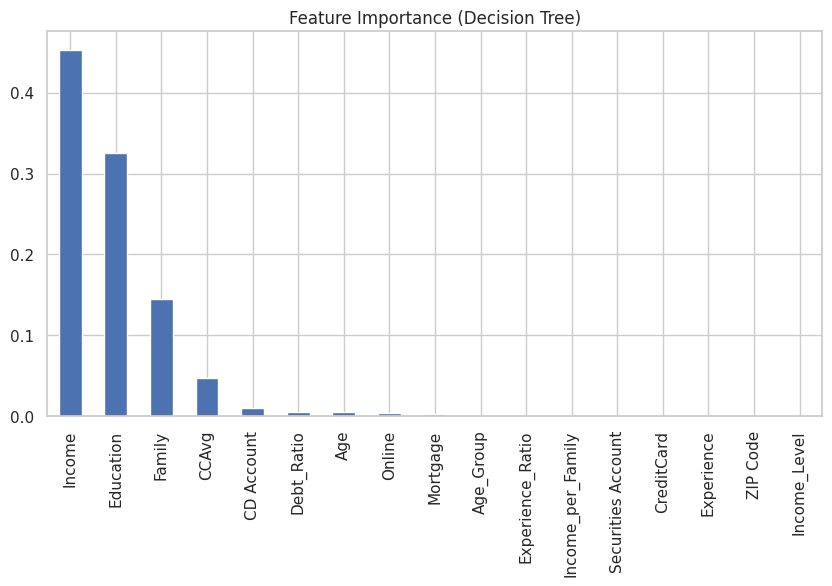

In [26]:
plt.figure(figsize=(10, 5))
importance = pd.Series(dt.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind="bar")
plt.title("Feature Importance (Decision Tree)")
plt.show()

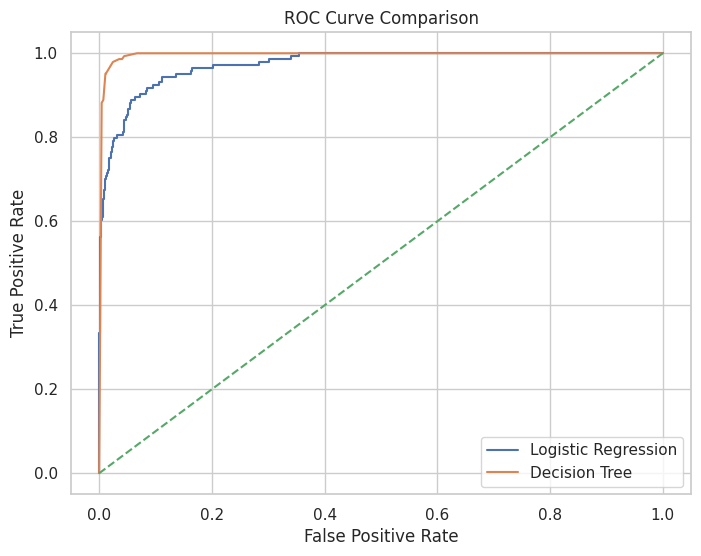

In [27]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, log_reg.predict_proba(X_test_scaled)[:, 1])
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt.predict_proba(X_test)[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_dt, tpr_dt, label="Decision Tree")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [28]:
print("\n================ BUSINESS INSIGHTS ================")
print("1. Income is the strongest predictor of loan acceptance.")
print("2. Customers with higher education are more likely to accept loans.")
print("3. High CCAvg (Credit Card Spending) strongly correlates with loan acceptance.")
print("4. Decision Tree indicates Income, Education, and CCAvg as top predictors.")
print("5. Bank should target high-income, credit-active customers for loan marketing.")
print("====================================================")


================ BUSINESS INSIGHTS ================
1. Income is the strongest predictor of loan acceptance.
2. Customers with higher education are more likely to accept loans.
3. High CCAvg (Credit Card Spending) strongly correlates with loan acceptance.
4. Decision Tree indicates Income, Education, and CCAvg as top predictors.
5. Bank should target high-income, credit-active customers for loan marketing.


In [30]:
# =========================
# 15. SAVE & REGISTER MODEL
# =========================

# Save both model and scaler (IMPORTANT for deployment)
import joblib
from azureml.core.model import Model
joblib.dump({
    "model": log_reg,
    "scaler": scaler
}, "bank_loan_model.pkl")

print("Model saved locally.")

# Register model in Azure
Model.register(
    workspace=ws,
    model_path="bank_loan_model.pkl",
    model_name="bank-loan-classification-model"
)

print("Model registered successfully in Azure.")

Model saved locally.
Registering model bank-loan-classification-model
Model registered successfully in Azure.
